# Setup python environment

In [11]:
%pip install pandas numpy matplotlib tensorflow scikit-learn

Note: you may need to restart the kernel to use updated packages.


# Constants

In [12]:
FEATURE_COLS = [
    "NO2",
    "C2H5OH",
    "VOC",
    "CO",
    "Alcohol",
    "LPG",
    "Benzene",
    "Temperature",
    "Pressure",
    "Humidity",
    "Gas_Resistance",
    "Altitude",
]
FEATURE_COLS_EXTENDED = FEATURE_COLS + [f"{c}_diff" for c in FEATURE_COLS]
TARGET_COL = "smell"
SEQ_LEN = 25
SMELLS = [
    "allspice",
    "almond",
    "angelica",
    "apple",
    "asparagus",
    "avocado",
    "banana",
    "brazil_nut",
    "broccoli",
    "brussel_sprouts",
    "cabbage",
    "cashew",
    "cauliflower",
    "chamomile",
    "chervil",
    "chestnuts",
    "chives",
    "cinnamon",
    "cloves",
    "coriander",
    "cumin",
    "dill",
    "garlic",
    "ginger",
    "hazelnut",
    "kiwi",
    "lemon",
    "mandarin_orange",
    "mango",
    "mint",
    "mugwort",
    "mustard",
    "nutmeg",
    "oregano",
    "peach",
    "peanuts",
    "pear",
    "pecans",
    "pili_nut",
    "pineapple",
    "pistachios",
    "potato",
    "radish",
    "saffron",
    "star_anise",
    "strawberry",
    "sweet_potato",
    "tomato",
    "turnip",
    "walnuts",
]

# Load Data

In [13]:
import os
import pandas as pd

def add_fotd_features(df: pd.DataFrame, feature_cols: list[str]) -> pd.DataFrame:
    df = df.copy()
    for col in feature_cols:
        df[col + "_diff"] = df[col].diff()
    df = df.fillna(0)
    return df


def load_dataset(base_dir: str) -> pd.DataFrame:
    dfs = []
    for folder in os.listdir(base_dir):
        if folder not in SMELLS: continue
        
        folder_path = os.path.join(base_dir, folder)
        if not os.path.isdir(folder_path):
            continue
        for file in os.listdir(folder_path):
            if not file.endswith(".csv"):
                continue
            fp = os.path.join(folder_path, file)
            df = pd.read_csv(fp)
            df[TARGET_COL] = folder
            df["sequence_id"] = file  # unique per recording
            df = add_fotd_features(df, FEATURE_COLS)
            dfs.append(df)
    if len(dfs) == 0:
        raise ValueError(f"No CSVs found under {base_dir}")
    return pd.concat(dfs, ignore_index=True)


training_data = load_dataset("../data/smellnet/offline_training")
testing_data  = load_dataset("../data/smellnet/offline_testing")

print(len(testing_data), " testing entries")
print(len(training_data), " training entries")

training_data.head()

30007  testing entries
150711  training entries


,NO2,C2H5OH,VOC,CO,Alcohol,LPG,Benzene,Temperature,Pressure,Humidity,...,VOC_diff,CO_diff,Alcohol_diff,LPG_diff,Benzene_diff,Temperature_diff,Pressure_diff,Humidity_diff,Gas_Resistance_diff,Altitude_diff
0,216,305,494,830,2,38,4294967295,25.53,1022.84,27.95,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.00
1,215,304,492,828,3,38,4294967295,25.53,1022.84,27.96,...,-2.0,-2.0,1.0,0.0,0.0,0.0,0.0,0.01,0.82,0.00
2,212,304,490,828,2,37,4294967295,25.53,1022.84,28.00,...,-2.0,0.0,-1.0,-1.0,0.0,0.0,0.0,0.04,0.65,0.00
3,211,302,488,828,2,37,4294967295,25.53,1022.84,28.03,...,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.03,0.55,0.00
4,210,301,487,827,2,39,4294967295,25.53,1022.84,28.06,...,-1.0,-1.0,0.0,2.0,0.0,0.0,0.0,0.03,0.68,0.08


# Neural Network

## Data preprocessing

In [14]:
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder


training_data["Gas_Resistance"] = np.log1p(training_data["Gas_Resistance"])
testing_data["Gas_Resistance"]  = np.log1p(testing_data["Gas_Resistance"])


label_encoder = LabelEncoder()
training_data['target_enc'] = label_encoder.fit_transform(training_data[TARGET_COL])
testing_data['target_enc']  = label_encoder.transform(testing_data[TARGET_COL])


NUM_CLASSES = len(label_encoder.classes_)


scaler = StandardScaler()
training_data_scaled = training_data.copy()
testing_data_scaled  = testing_data.copy()

training_data_scaled[FEATURE_COLS_EXTENDED] = scaler.fit_transform(training_data[FEATURE_COLS_EXTENDED])
testing_data_scaled[FEATURE_COLS_EXTENDED]  = scaler.transform(testing_data[FEATURE_COLS_EXTENDED])

## Create sequences

In [15]:
from collections import defaultdict
import numpy as np

def create_sequences_grouped(df: pd.DataFrame, feature_cols: list[str], target_col: str, seq_len: int):
    X, y = [], []

    for _, group in df.groupby("sequence_id"):
        data = group[feature_cols].values
        labels = group[target_col].values

        if len(group) < seq_len:
            continue

        for i in range(len(group) - seq_len + 1):
            # double check all the samples in a sequence are of same smell
            # if not all([l == labels[i+seq_len-1] for l in labels[i:i+seq_len]]):  
            #     print("Skipped invalid sequence")
            #     continue

            X.append(data[i:i+seq_len])
            y.append(labels[i+seq_len-1])

    return np.array(X), np.array(y)


seq_labels = (
    training_data_scaled
    .groupby("sequence_id")["target_enc"]
    .first()
)

class_to_sequences = defaultdict(list)

for seq_id, label in seq_labels.items():
    class_to_sequences[label].append(seq_id)

train_ids = []
val_ids = []

for label, seqs in class_to_sequences.items():
    seqs = np.array(seqs)
    np.random.shuffle(seqs)

    # 5 sequences for each smell
    # use one for validation so no overlap in sequence samples
    val_ids.append(seqs[0])
    train_ids.extend(seqs[1:])

train_df = training_data_scaled[training_data_scaled["sequence_id"].isin(train_ids)]
val_df = training_data_scaled[training_data_scaled["sequence_id"].isin(val_ids)]

X_train_seq, y_train_seq = create_sequences_grouped(train_df, FEATURE_COLS_EXTENDED, 'target_enc', SEQ_LEN)
X_val_seq, y_val_seq = create_sequences_grouped(val_df, FEATURE_COLS_EXTENDED, 'target_enc', SEQ_LEN)

X_test_seq,  y_test_seq  = create_sequences_grouped(testing_data_scaled,  FEATURE_COLS_EXTENDED, 'target_enc', SEQ_LEN)

print("X_train_seq shape:", X_train_seq.shape)
print("y_train_seq shape:", y_train_seq.shape)
print("X_test_seq shape:", X_test_seq.shape)
print("y_test_seq shape:", y_test_seq.shape)

X_train_seq shape: (116057, 25, 24)
y_train_seq shape: (116057,)
X_test_seq shape: (28807, 25, 24)
y_test_seq shape: (28807,)


## Build model

In [16]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, Input

model = Sequential()
model.add(Input(shape=(SEQ_LEN, len(FEATURE_COLS_EXTENDED))))
model.add(LSTM(32, return_sequences=False))
model.add(Dropout(0.3))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(NUM_CLASSES, activation='softmax'))

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 32)             │         7,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 50)             │         1,650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,002 (39.07 KB)

 Trainable params: 10,002 (39.07 KB)

 Non-trainable params: 0 (0.00 B)

## Train model

In [17]:
from keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(X_train_seq, y_train_seq,
                    validation_data=(X_val_seq, y_val_seq),
                    epochs=30,
                    batch_size=64,
                    callbacks=[early_stop],
                    shuffle=True)

Epoch 1/30
1814/1814 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.5735 - loss: 1.3095 - val_accuracy: 0.8539 - val_loss: 0.5119
Epoch 2/30
1814/1814 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8207 - loss: 0.5013 - val_accuracy: 0.8975 - val_loss: 0.4475
Epoch 3/30
1814/1814 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8751 - loss: 0.3660 - val_accuracy: 0.8901 - val_loss: 0.4386
Epoch 4/30
1814/1814 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9031 - loss: 0.2858 - val_accuracy: 0.9136 - val_loss: 0.3926
Epoch 5/30
1814/1814 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9131 - loss: 0.2625 - val_accuracy: 0.8699 - val_loss: 0.6675
Epoch 6/30
1814/1814 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9291 - loss: 0.2189 - val_accuracy: 0.8863 - val_loss: 0.6132
Epoch 7/30
1814/1814 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9358 - loss: 0.2005 - val_accuracy: 0.8897 - val_loss: 0.4912
Epoch 8/30
1814/1814 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9404 - loss: 0

## Evaluate model

In [18]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

y_pred_probs = model.predict(X_test_seq)
y_pred = np.argmax(y_pred_probs, axis=1)

overall_acc = accuracy_score(y_test_seq, y_pred)
print("Overall Test Accuracy:", overall_acc)

# Confusion matrix for all classes (force full label range)
labels_full = np.arange(NUM_CLASSES)
cm = confusion_matrix(y_test_seq, y_pred, labels=labels_full)

# per-class accuracy (handle zero samples)
denom = cm.sum(axis=1)
per_class_acc = np.divide(cm.diagonal(), denom,
                          out=np.zeros_like(cm.diagonal(), dtype=float),
                          where=denom!=0)

class_names = label_encoder.inverse_transform(labels_full)

for name, acc, n in zip(class_names, per_class_acc, denom):
    print(f"{name:20s} : {acc:.3f}  (n_test={int(n)})")

print("\nClassification Report (only shows classes present in y_test):")
print(classification_report(y_test_seq, y_pred, labels=np.unique(y_test_seq),
                            target_names=label_encoder.inverse_transform(np.unique(y_test_seq))))


901/901 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
Overall Test Accuracy: 0.8160169403270039
allspice             : 0.998  (n_test=560)
almond               : 1.000  (n_test=605)
angelica             : 1.000  (n_test=633)
apple                : 0.002  (n_test=582)
asparagus            : 1.000  (n_test=557)
avocado              : 0.077  (n_test=569)
banana               : 1.000  (n_test=541)
brazil_nut           : 1.000  (n_test=580)
broccoli             : 0.940  (n_test=504)
brussel_sprouts      : 0.883  (n_test=566)
cabbage              : 1.000  (n_test=640)
cashew               : 0.310  (n_test=575)
cauliflower          : 1.000  (n_test=567)
chamomile            : 0.039  (n_test=585)
chervil              : 1.000  (n_test=578)
chestnuts            : 0.980  (n_test=590)
chives               : 0.373  (n_test=608)
cinnamon             : 0.727  (n_test=553)
cloves               : 0.893  (n_test=591)
coriander            : 1.000  (n_test=580)
cumin                : 0.917  (n_test=580)
dill          

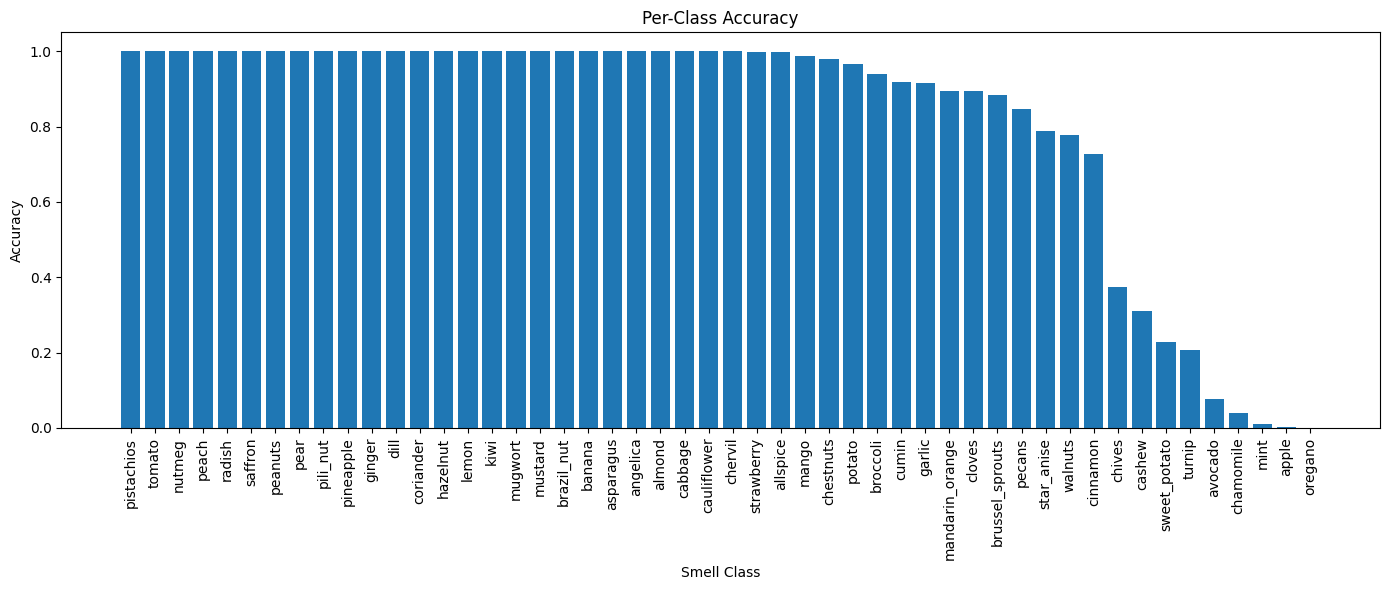

In [19]:
import matplotlib.pyplot as plt

sorted_idx = np.argsort(per_class_acc)[::-1]
sorted_acc = per_class_acc[sorted_idx]
sorted_names = class_names[sorted_idx]

plt.figure(figsize=(14,6))
plt.bar(sorted_names, sorted_acc)
plt.xticks(rotation=90)
plt.ylabel("Accuracy")
plt.xlabel("Smell Class")
plt.title("Per-Class Accuracy")
plt.tight_layout()
plt.show()